In [1]:
from utils import run_proteus_parallel
import numpy as np
import pandas as pd
import os

from utils import run_proteus

import torch
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood

from scipy.stats.qmc import Halton
from sklearn.preprocessing import StandardScaler

from botorch.acquisition import ExpectedImprovement, UpperConfidenceBound, qLogExpectedImprovement, qExpectedImprovement

from botorch.optim import optimize_acqf

import matplotlib.pyplot as plt

device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
dtype = torch.double


In [2]:
print(os.getcwd())
os.chdir("..")
print(os.getcwd())

/Users/benriegler/Documents/BO_Lichtenberg/PROTEUS/play_dummy
/Users/benriegler/Documents/BO_Lichtenberg/PROTEUS


In [3]:
data_path = "play_dummy/synth_data/struct.corefrac.csv"

# pick the ones that vary
output = pd.read_csv(data_path, delimiter= "\t")[["contrast_ratio",
                                               "M_planet",
                                               "R_int",
                                               "transit_depth"]]

param = pd.read_csv(data_path, delimiter= "\t")[["index"]]

out_scaler = StandardScaler()

# work with standardized observables to keep objective at reasonable size
output = out_scaler.fit_transform(torch.tensor(output.values))

# parameters will be MinMax scaled internally by BoTorch
param = torch.tensor(param.values)


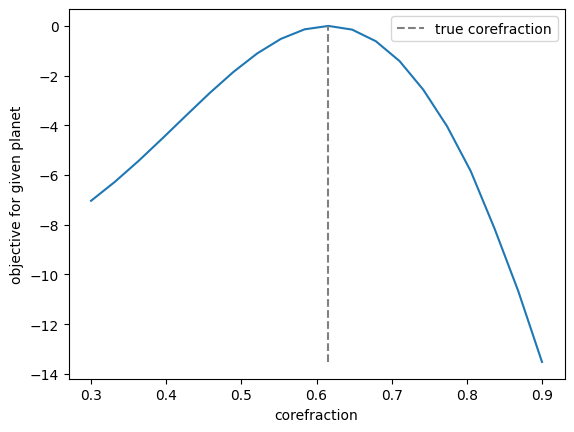

In [4]:
# choose planet from synthetic data

obs = output[10,:]; x = param[10,:]

# calculate discretized objective

f = -((output-obs)**2).sum(1)

# plot objective over normalized input

plt.plot(param, f)
plt.vlines(x,f.min(), f.max(), color = "grey", linestyles= "--", label="true corefraction")

plt.xlabel("corefraction")
plt.ylabel("objective for given planet")

plt.legend()

plt.show()

In [5]:
def J(x, obs):

    """
    Get objecitve values at q-batch

    Input:
        x (tensor): q x d dimensional input batch
        obs (tensor): the observables of the plante under investigation

    Output:
        J (tensor): q x 1 dimensional objective values
    """

    # change only the corefrac and keep rest fixed at dummy config/ at config of synthetic DGP

    # the observables of interest here
    observables = [ "contrast_ratio",
                    "M_planet",
                    "R_int",
                    "transit_depth"]

    q = len(x)
    run_names = [f"BO/workers/worker{i}" for i in range(q)]

    par = [{"struct.corefrac": i.item()} for i in x]

    inputs = list(zip(par, run_names))

    if __name__ == '__main__':

        sim = run_proteus_parallel(inputs, q, obs = observables)

    sim = [torch.tensor(i.values).reshape(1, -1) for i in sim]
    sim = [out_scaler.transform(i) for i in sim]
    J = np.array([-((obs-i)**2).sum().reshape(1,1) for i in sim])
    J = torch.tensor(J).reshape(q, 1)

    return J, sim

In [6]:
# the optimium and the optimizer
print(J(x,obs))
print(x)

1 runs took: 5.21 seconds
(tensor([[-0.]], dtype=torch.float64), [array([[0.03673628, 0.00461837, 0.07222472, 0.03939936]])])
tensor([0.6158], dtype=torch.float64)


In [7]:
bounds = torch.tensor([[0.3], [0.9]], device=device, dtype=dtype)

NUM_RESTARTS = 10
RAW_SAMPLES = 50


def optimize_acqf_and_get_observation(acq_func, obs,  q):
    """Optimizes the acquisition function, and returns a new candidate and observation."""
    # optimize

    candidates, _ = optimize_acqf(
        acq_function=acq_func,
        bounds=bounds,
        q=q,
        num_restarts=NUM_RESTARTS,
        raw_samples=RAW_SAMPLES,  # used for intialization heuristic
        options={"batch_limit": 5, "maxiter": 200},
    )
    # observe new values
    new_x = candidates.detach()
    new_y = J(new_x, obs)[0]

    return new_x, new_y

def init_model(train_X, train_Y):

    gp = SingleTaskGP(
    train_X=train_X,
    train_Y=train_Y,
    input_transform=Normalize(d=1),
    outcome_transform=Standardize(m=1),
    )

    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)

    return mll, gp

def plot_iteration(acqf, train_X, train_Y, model):

    test_X = torch.linspace(bounds[0].item(),bounds[1].item(), 100)[:, None][:, None] # batch_shape x q=1 x d for acqf

    post = model.posterior(test_X)

    mean = post.mean.detach().numpy().flatten()
    # var = post.variance.detach().numpy().flatten()

    # a = acqf(test_X).detach().numpy()

    test_X = test_X.flatten()

    plt.plot(param, f, label = "f", linewidth = 0.5, color = "grey")

    # plt.plot(test_X, a, label = "acqf")

    plt.scatter(train_X, train_Y)

    plt.plot(test_X, mean, label = "post_mean")

    plt.legend()

    plt.show()

1 runs took: 4.92 seconds


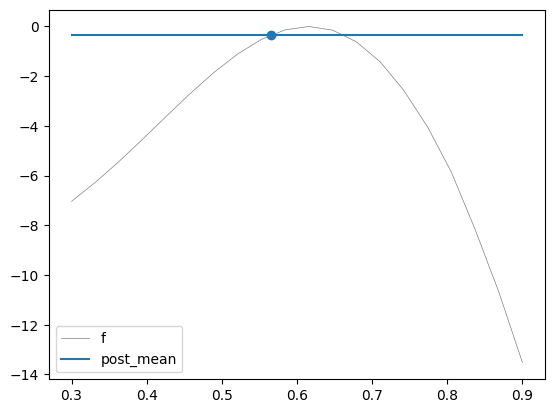

starting iteration 1
4 runs took: 7.25 seconds


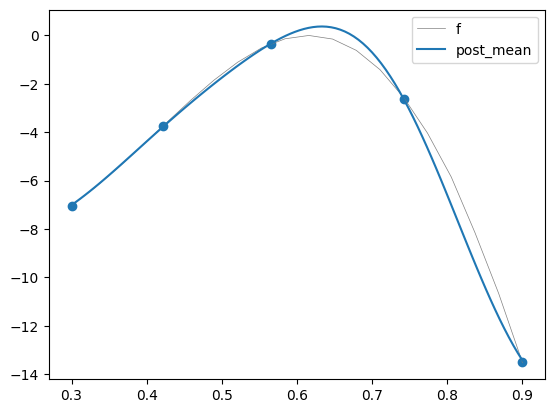

starting iteration 2
4 runs took: 6.30 seconds


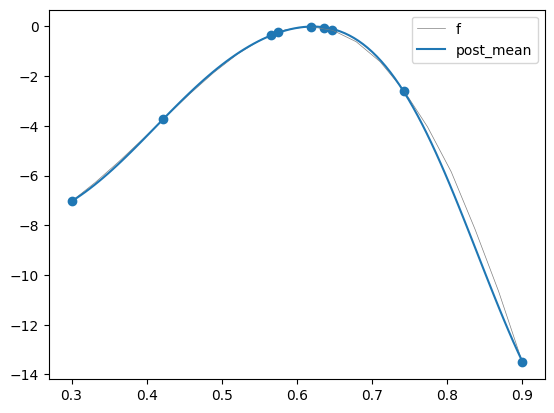

best obj: -0.0012953383094541926
est: tensor([[0.6188]], dtype=torch.float64)
true: tensor([0.6158], dtype=torch.float64)


In [8]:
NUM_ITER = 2

BATCH_SIZE = 4

# init data
n_init = 1


halton_sampler = Halton(d=1, scramble=True)
train_X = halton_sampler.random(n=n_init)
train_X = torch.tensor(train_X, dtype= torch.double) * (bounds[1] - bounds[0]) + bounds[0]

# train_X = (torch.rand(n_init, dtype=dtype) * (bounds[1] - bounds[0]) + bounds[0])


train_Y = J(train_X, obs)[0]
best_y = train_Y.max()
#best_x = train_X.item()

mll, gp = init_model(train_X, train_Y)
fit_gpytorch_mll(mll)

# acqf = UpperConfidenceBound(model=gp, beta=0.7)
# acqf = ExpectedImprovement(gp, best_y)
acqf = qLogExpectedImprovement(gp,best_y)

plot_iteration(acqf, train_X, train_Y, gp)

for i in range(NUM_ITER):
    print(f"starting iteration {i+1}")

    new_x, new_y = optimize_acqf_and_get_observation(acqf, obs, BATCH_SIZE)

    M_new = new_y.max()

    if M_new > best_y:
        best_y = M_new
        best_x = new_x[torch.argmax(new_y)][None, :]

    train_X = torch.cat([train_X, new_x])
    train_Y = torch.cat([train_Y, new_y])

    mll, gp = init_model(train_X, train_Y)

    fit_gpytorch_mll(mll)

    # acqf = UpperConfidenceBound(model=gp, beta=0.7)
    # acqf = ExpectedImprovement(gp, best_y)
    acqf = qLogExpectedImprovement(gp,best_y)

    plot_iteration(acqf, train_X, train_Y, gp)


print(f"best obj: {best_y}")
print(f"est: {best_x}") # could also choose to return max of posterior mean
print(f"true: {x}")
